# 02 — Pré-processamento

**Objetivo:** Tratar valores ausentes, remover features redundantes, aplicar
normalização/padronização e dividir em conjuntos de treino e teste.

In [4]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_breast_cancer_data

df = load_breast_cancer_data()
df.shape

(569, 31)

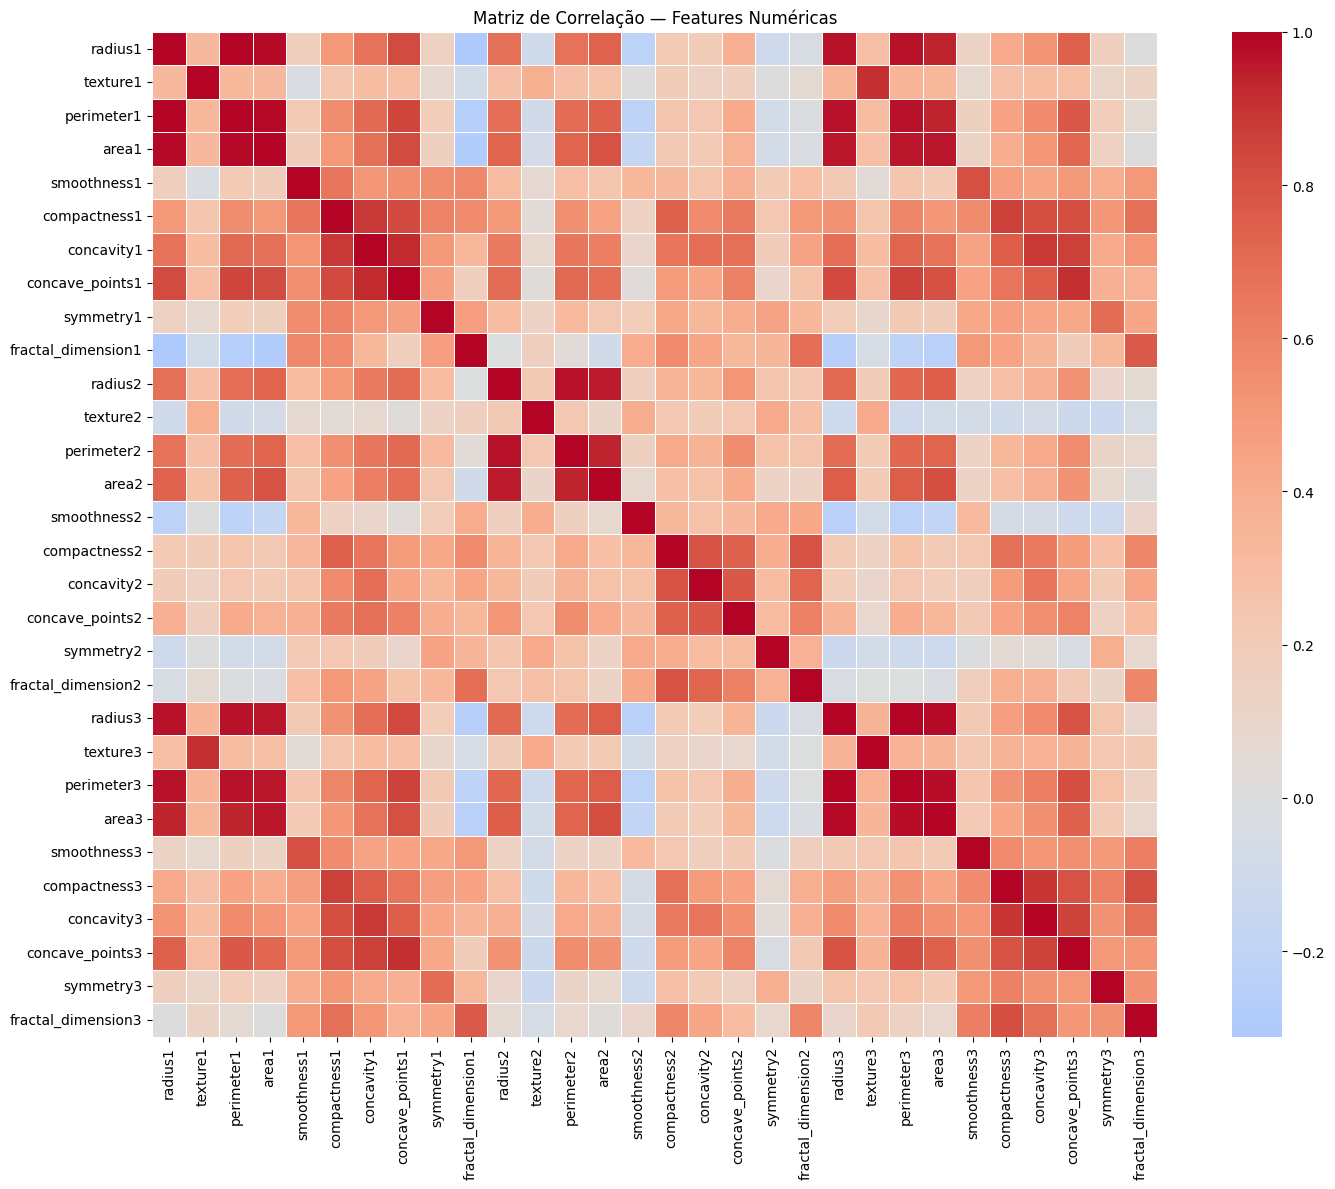

In [5]:
corr_matrix = df.drop(columns=['diagnosis']).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            annot=False, square=True, linewidths=0.5)
plt.title('Matriz de Correlação — Features Numéricas')
plt.tight_layout()
plt.show()

In [6]:
df_temp = df.copy()
df_temp['diagnosis_num'] = (df_temp['diagnosis'] == 'M').astype(int)

corr_com_target = df_temp.drop(columns=['diagnosis']).corr()['diagnosis_num'].sort_values(ascending=False)
corr_com_target.drop('diagnosis_num')

concave_points3       0.793566
perimeter3            0.782914
concave_points1       0.776614
radius3               0.776454
perimeter1            0.742636
area3                 0.733825
radius1               0.730029
area1                 0.708984
concavity1            0.696360
concavity3            0.659610
compactness1          0.596534
compactness3          0.590998
radius2               0.567134
perimeter2            0.556141
area2                 0.548236
texture3              0.456903
smoothness3           0.421465
symmetry3             0.416294
texture1              0.415185
concave_points2       0.408042
smoothness1           0.358560
symmetry1             0.330499
fractal_dimension3    0.323872
compactness2          0.292999
concavity2            0.253730
fractal_dimension2    0.077972
symmetry2            -0.006522
texture2             -0.008303
fractal_dimension1   -0.012838
smoothness2          -0.067016
Name: diagnosis_num, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)  # 1 = Maligno, 0 = Benigno

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print(f"\nProporção de Maligno no treino: {y_train.mean():.3f}")
print(f"Proporção de Maligno no teste: {y_test.mean():.3f}")

Treino: 455 amostras
Teste: 114 amostras

Proporção de Maligno no treino: 0.374
Proporção de Maligno no teste: 0.368


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']].head()

,mean,std
radius1,-1.737316e-16,1.001101
texture1,3.904081e-16,1.001101
perimeter1,4.704418e-16,1.001101
area1,-1.171224e-16,1.001101
smoothness1,7.242070e-16,1.001101
